# Transit window-label quality check (KP/CP diagnostic)

Experimental, reversible diagnostic (canonical `{CP,KP,PC,APC}` labels untouched). Reads the **rich per-window annotation** `labels/qc/transit_window_labels_w256_annot.parquet` (built by `src/qc/build_transit_window_labels.py --emit annot`): for every window of every transit-positive star it records the best disposition that **fully contains** a transit (`full_best`), only **partially** clips one (`part_best`), or sits in the **near buffer** only (`near_best`).

The 1/0/-1 label is **not** baked — it is derived per **knob** so you can flip two switches live:
- `DISP_SET` — which dispositions count as a real transit: `{CP,KP}` or `{CP,KP,PC}`.
- `INCLUDE_PARTIAL` — whether an edge-clipped (partial) transit also counts as `transit=1`.

A `label=1` window must contain (or, with partial on, clip) the shaded predicted transit. The size×purity table reports, per knob, the positive-window **count** and the fraction of those windows that actually show a fold dip (`depth>0`, `SNR>3`). Ephemerides (P, T0, duration, disposition; BTJD) come from `labels/qc/toi_nasa.csv`.

In [1]:
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

root = Path.cwd()
while not (root / "CLAUDE.md").exists():
    root = root.parent
sys.path.insert(0, str(root / "src" / "qc"))
from transit_window_coverage import _median_duration, load_ephemerides_with_disp
from build_transit_window_labels import NEAR_FACTOR, index_npz_by_segment, replay_segment

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("sanity")

# Rich per-window annotation over the full {CP,KP,PC,APC} whitelist; the 1/0/-1 label is derived per
# knob two cells down (disposition subset x include-partial), so the same fold serves every knob.
annot = pd.read_parquet(root / "labels" / "qc" / "transit_window_labels_w256_annot.parquet")
eph = load_ephemerides_with_disp(root / "labels" / "qc" / "toi_nasa.csv", logger)  # {tic: [(P, T0, dur, disp)]}
median_dur = _median_duration(eph)
print("annotation rows:", len(annot), "| transit stars:", annot["tic_id"].nunique())
annot[["full_best", "part_best", "near_best"]].apply(lambda c: c.value_counts()).fillna(0).astype(int)

INFO:sanity:ephemerides+disp: 6625 TOI rows over 6351 TICs (whitelist=['APC', 'CP', 'KP', 'PC'], finite P+T0)


annotation rows: 95956 | transit stars: 813


,full_best,part_best,near_best
,89956,91782,91924
PC,3236,2551,2446
CP,1458,803,828
APC,1013,461,390
KP,293,359,368


## Knobs — flip these, then re-run the cells below

Two independent switches. `DISP_SET` = which dispositions count as a real transit (`{CP,KP}` for the strict KP+CP knob, `{CP,KP,PC}` to also admit planet candidates). `INCLUDE_PARTIAL` = whether a partial (window-edge-clipped) transit also counts as `transit=1`. A `near_best`-only window (no in-transit cadence) **never** counts as positive. Everything with overlap that isn't positive is quarantined; a window with no overlap at all is a clean negative regardless of knob.

In [2]:
# ---- KNOBS: edit these two, then re-run the plot cells below ---------------
DISP_SET = {"CP", "KP"}          # (1) KP+CP   ->  set to {"CP", "KP", "PC"} for (2) KP+CP+PC
INCLUDE_PARTIAL = False          # (3) True: also count partial (edge-clipped) transits as transit=1
# ---------------------------------------------------------------------------


def derive_label(df, disp_set, include_partial):
    """Per-window 1/0/-1 transit label under one knob.

    1  positive  : a whole transit of a disp_set TOI is contained (or, if include_partial, a disp_set
                   TOI is partially in the window)
    0  negative  : no overlap of any kind from any TOI (knob-independent)
    -1 quarantine: overlap present but not positive -- wrong disposition, near-buffer only, partial
                   when include_partial is off, or an unfoldable transit star
    """
    full_hit = df["full_best"].isin(disp_set)
    part_hit = include_partial & df["part_best"].isin(disp_set)
    pos = full_hit | part_hit
    overlap = (df["full_best"] != "") | (df["part_best"] != "") | (df["near_best"] != "") | df["unfoldable"]
    return pd.Series(np.where(pos, 1, np.where(overlap, -1, 0)).astype(np.int8), index=df.index)


derive_label(annot, DISP_SET, INCLUDE_PARTIAL).value_counts()

 0    76514
-1    17691
 1     1751
Name: count, dtype: int64

One scandir pass indexes the transit stars' sequence files so each plot/fold cell can load a segment without globbing the 416k-file directory.

In [3]:
transit_tics = set(annot["tic_id"].unique())
npz_index = index_npz_by_segment(root / "processed" / "sequences", transit_tics, logger)

INFO:sanity:indexed 5903 npz across 5903 segments for 813 transit TICs


## Size × purity per knob

`n_pos` = positive-window count (**label size** — the thing you care about). `frac_depth>0` / `frac_SNR>3` = **purity**: of those positive windows, the fraction that actually show a fold dip. The strict KP+CP-full knob should trade size for the highest purity; each loosening (add PC, add partial) grows `n_pos` — watch whether purity drops. `n_neg` is knob-independent (clean negatives = no overlap at all). The depth/SNR pass loads one npz per segment, so it takes ~a minute the first time.

In [4]:
def _window_depth_snr(times_row, flux_row, toi_rows):
    """Fold-dip depth (MAD units) + SNR for one 256-window, using the star's TOIs (union in-transit mask).
    depth = median(out-of-transit flux) - median(in-transit flux); >0 means a dip is present."""
    t = times_row.astype(np.float64)
    in_mask = np.zeros(t.shape, dtype=bool)
    for (P, T0, dur, _disp) in toi_rows:
        d = dur if np.isfinite(dur) else median_dur
        phase = np.mod(t - T0 + 0.5 * P, P) - 0.5 * P
        in_mask |= np.abs(phase) <= 0.5 * d
    base = ~in_mask
    if in_mask.sum() < 3 or base.sum() < 10:
        return np.nan, np.nan
    depth = float(np.median(flux_row[base]) - np.median(flux_row[in_mask]))
    noise = 1.4826 * float(np.median(np.abs(flux_row[base] - np.median(flux_row[base]))))
    snr = depth / (noise / np.sqrt(in_mask.sum())) if noise > 0 else np.nan
    return depth, snr


# depth/SNR is knob-independent per window; compute it once on the loosest knob's positives (a superset
# of every knob's positives), grouping by segment so each npz loads once, then reuse for all knobs.
superset = annot[derive_label(annot, {"CP", "KP", "PC"}, True) == 1]
ds_map = {}
for (tic, sector, seg_idx), grp in tqdm(superset.groupby(["tic_id", "sector", "seg_idx"]), desc="depth/snr"):
    key = (int(tic), int(sector), int(seg_idx))
    if key not in npz_index:
        continue
    times, flux = replay_segment(npz_index[key][0], 256, 20.0)
    toi_rows = eph.get(int(tic), [])
    for r in grp.itertuples(index=False):
        ds_map[int(r.row)] = _window_depth_snr(times[int(r.win_in_seg)], flux[int(r.win_in_seg)], toi_rows)
annot["depth"] = annot["row"].map(lambda r: ds_map.get(int(r), (np.nan, np.nan))[0])
annot["snr"] = annot["row"].map(lambda r: ds_map.get(int(r), (np.nan, np.nan))[1])

KNOBS = [("KP+CP", {"CP", "KP"}, False), ("KP+CP +part", {"CP", "KP"}, True),
         ("KP+CP+PC", {"CP", "KP", "PC"}, False), ("KP+CP+PC +part", {"CP", "KP", "PC"}, True)]
rows = []
for name, dsv, ip in KNOBS:
    lab = derive_label(annot, dsv, ip)
    pos = annot[lab == 1]
    rows.append({"knob": name, "n_pos": int((lab == 1).sum()), "n_quar": int((lab == -1).sum()),
                 "n_neg": int((lab == 0).sum()), "n_stars_pos": int(pos["tic_id"].nunique()),
                 "frac_depth>0": round(float((pos["depth"] > 0).mean()), 3),
                 "frac_SNR>3": round(float((pos["snr"] > 3).mean()), 3)})
pd.DataFrame(rows)

depth/snr:   0%|          | 0/3201 [00:00<?, ?it/s]

,knob,n_pos,n_quar,n_neg,n_stars_pos,frac_depth>0,frac_SNR>3
0,KP+CP,1751,17691,76514,217,0.915,0.657
1,KP+CP +part,2903,16539,76514,253,0.901,0.683
2,KP+CP+PC,4987,14455,76514,530,0.841,0.488
3,KP+CP+PC +part,8678,10764,76514,620,0.817,0.485


The plot helper is shared by the positive and quarantine cells below. Dark band = predicted in-transit interval (half-width 0.5 duration), light band = the quarantine buffer (NEAR_FACTOR durations from mid-transit).

In [7]:
def plot_window(row):
    """Plot one packed 256-cadence window's MAD-normalized flux vs BTJD, shading the star's predicted
    transits. Dark band = in-transit interval (half-width 0.5 duration), light band = near buffer
    (NEAR_FACTOR durations from mid-transit)."""
    key = (int(row.tic_id), int(row.sector), int(row.seg_idx))
    times, flux = replay_segment(npz_index[key][0], 256, 20.0)
    t = times[int(row.win_in_seg)]
    f = flux[int(row.win_in_seg)]
    plt.figure(figsize=(10, 4))
    plt.plot(t, f, linewidth=0.8)
    for P, T0, dur, disp in eph.get(int(row.tic_id), []):
        d = dur if np.isfinite(dur) else median_dur
        k0 = int(np.floor((t.min() - T0) / P)) - 1
        k1 = int(np.ceil((t.max() - T0) / P)) + 1
        for k in range(k0, k1 + 1):
            mid = T0 + k * P
            plt.axvspan(mid - NEAR_FACTOR * d, mid + NEAR_FACTOR * d, color="orange", alpha=0.15)
            plt.axvspan(mid - 0.5 * d, mid + 0.5 * d, color="crimson", alpha=0.3)
    plt.xlim(t.min(), t.max())
    plt.xlabel("time (BTJD, d)")
    plt.ylabel("flux (MAD units)")
    plt.title(f"TIC {row.tic_id} | {row.seg_id} win {row.win_in_seg} | "
              f"full={row.full_best or '-'} part={row.part_best or '-'} near={row.near_best or '-'} | "
              f"in-transit cadences {row.n_intransit_cad}")
    plt.show()

## Random `transit=1` window (active knob)

Samples a positive window under the current `DISP_SET` / `INCLUDE_PARTIAL`. Under the strict knob the dark band should sit **fully inside** the plotted window; with `INCLUDE_PARTIAL=True` it may be clipped by the window edge. The dip can still be shallow (hours-long, weak-signal events). Re-run for a fresh sample.

knob DISP_SET=['CP', 'KP'] INCLUDE_PARTIAL=False: 1751 positive windows


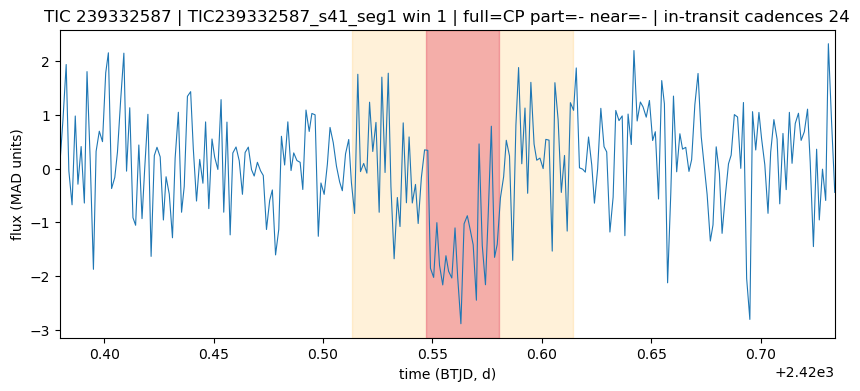

In [65]:
rng = np.random.default_rng()
# rng = np.random.default_rng(0)  # uncomment for a reproducible sample
pos = annot[derive_label(annot, DISP_SET, INCLUDE_PARTIAL) == 1]
print(f"knob DISP_SET={sorted(DISP_SET)} INCLUDE_PARTIAL={INCLUDE_PARTIAL}: {len(pos)} positive windows")
plot_window(pos.iloc[rng.integers(len(pos))])

## Random quarantine window that clips a transit (`part_best` set)

The interesting near-miss case: a window that catches part of a transit but not the whole thing, so it is quarantined (not a positive) under the active knob unless `INCLUDE_PARTIAL` is on. The dark in-transit band should touch the window edge without being fully contained.

In [ ]:
rng = np.random.default_rng()
# rng = np.random.default_rng(0)  # uncomment for a reproducible sample
lab = derive_label(annot, DISP_SET, INCLUDE_PARTIAL)
# quarantine windows that actually clip a transit (part_best set) -- the near-miss the full-transit rule excludes
quar = annot[(lab == -1) & (annot["part_best"] != "")]
plot_window(quar.iloc[rng.integers(len(quar))])

## Random positive star's full segment

Context view: the whole contiguous segment with its predicted transits, showing how the 256-cadence windows slice the events.

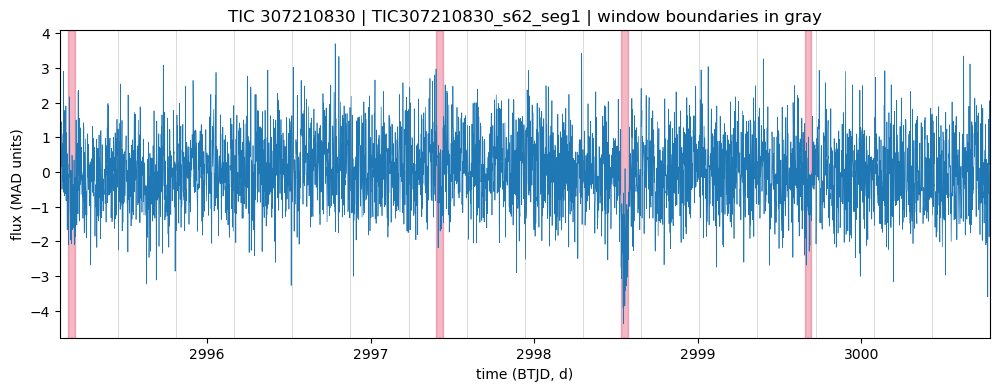

In [16]:
rng = np.random.default_rng()
# rng = np.random.default_rng(0)  # uncomment for a reproducible sample
pos = annot[derive_label(annot, DISP_SET, INCLUDE_PARTIAL) == 1]
seg_ids = pos["seg_id"].unique()
seg_rows = annot[annot["seg_id"] == seg_ids[rng.integers(len(seg_ids))]]
first = seg_rows.iloc[0]
key = (int(first.tic_id), int(first.sector), int(first.seg_idx))
times, flux = replay_segment(npz_index[key][0], 256, 20.0)
plt.figure(figsize=(12, 4))
plt.plot(times.reshape(-1), flux.reshape(-1), linewidth=0.5)
for P, T0, dur, disp in eph.get(int(first.tic_id), []):
    d = dur if np.isfinite(dur) else median_dur
    for k in range(int(np.floor((times.min() - T0) / P)) - 1, int(np.ceil((times.max() - T0) / P)) + 2):
        plt.axvspan(T0 + k * P - 0.5 * d, T0 + k * P + 0.5 * d, color="crimson", alpha=0.3)
for t_win in times:
    plt.axvline(t_win[0], color="gray", linewidth=0.4, alpha=0.5)
plt.xlim(times.min(), times.max())
plt.xlabel("time (BTJD, d)")
plt.ylabel("flux (MAD units)")
plt.title(f"TIC {first.tic_id} | {first.seg_id} | window boundaries in gray")
plt.show()